Using cuda device


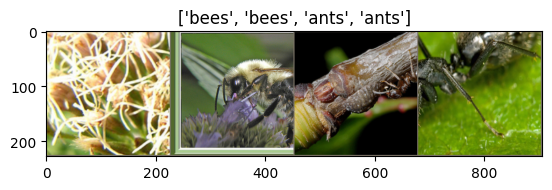

Epoch 0/24
----------
train Loss: 0.5611 Acc: 0.6844
val Loss: 0.2858 Acc: 0.8758

Epoch 1/24
----------
train Loss: 0.6338 Acc: 0.7746
val Loss: 0.2608 Acc: 0.9216

Epoch 2/24
----------
train Loss: 0.3610 Acc: 0.8238
val Loss: 0.4400 Acc: 0.8497

Epoch 3/24
----------
train Loss: 0.4863 Acc: 0.7951
val Loss: 0.7398 Acc: 0.7451

Epoch 4/24
----------
train Loss: 0.5748 Acc: 0.7623
val Loss: 0.3210 Acc: 0.8824

Epoch 5/24
----------
train Loss: 0.4219 Acc: 0.8197
val Loss: 0.3844 Acc: 0.9150

Epoch 6/24
----------
train Loss: 0.5313 Acc: 0.7992
val Loss: 0.2626 Acc: 0.8889

Epoch 7/24
----------
train Loss: 0.2586 Acc: 0.8730
val Loss: 0.2202 Acc: 0.9216

Epoch 8/24
----------
train Loss: 0.2720 Acc: 0.8852
val Loss: 0.2261 Acc: 0.9216

Epoch 9/24
----------
train Loss: 0.3868 Acc: 0.8566
val Loss: 0.2020 Acc: 0.9216

Epoch 10/24
----------
train Loss: 0.2563 Acc: 0.8730
val Loss: 0.1980 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.3082 Acc: 0.8648
val Loss: 0.2050 Acc: 0.9281

Ep

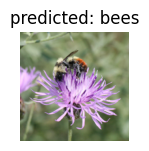

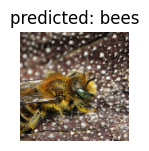

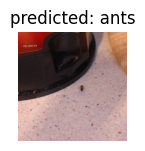

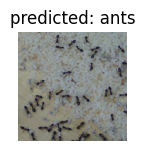

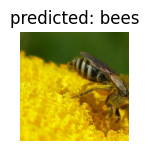

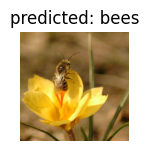

Epoch 0/24
----------
train Loss: 0.7236 Acc: 0.6311
val Loss: 0.2857 Acc: 0.8889

Epoch 1/24
----------
train Loss: 0.6748 Acc: 0.7377
val Loss: 0.6832 Acc: 0.7386

Epoch 2/24
----------
train Loss: 0.9073 Acc: 0.6516
val Loss: 0.1970 Acc: 0.9346

Epoch 3/24
----------
train Loss: 0.4826 Acc: 0.7869
val Loss: 0.2144 Acc: 0.9281

Epoch 4/24
----------
train Loss: 0.4815 Acc: 0.8033
val Loss: 0.3418 Acc: 0.8824

Epoch 5/24
----------
train Loss: 0.5080 Acc: 0.7787
val Loss: 0.1731 Acc: 0.9412

Epoch 6/24
----------
train Loss: 0.4097 Acc: 0.8484
val Loss: 0.1813 Acc: 0.9477

Epoch 7/24
----------
train Loss: 0.4161 Acc: 0.8361
val Loss: 0.1656 Acc: 0.9542

Epoch 8/24
----------
train Loss: 0.3353 Acc: 0.8484
val Loss: 0.1918 Acc: 0.9412

Epoch 9/24
----------
train Loss: 0.3433 Acc: 0.8648
val Loss: 0.1718 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.4227 Acc: 0.8156
val Loss: 0.1784 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3736 Acc: 0.8402
val Loss: 0.1699 Acc: 0.9542

Ep

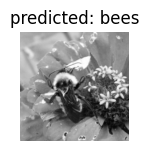

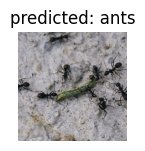

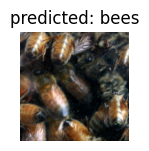

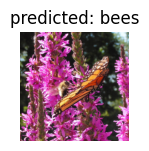

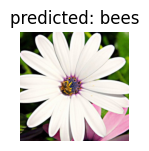

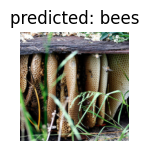

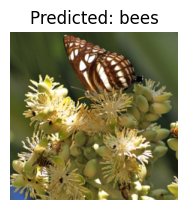

In [2]:
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

# Load data

# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

#!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
#!unzip hymenoptera_data.zip

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Visualize a few images so as to understand the data augmentation

def imshow(inp, title=None):
    """Display image for Tensor"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from the batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

# Traing the model general function
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f"Epoch {epoch}/{num_epochs - 1}")
            print("-" * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad() 

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    
                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()
                
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()
    
        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

# Visualize the model predictions
# Generic function to display predictions for a few images

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# Finetuning the ConvNet
# Load a pretrained model and reset final fully connected layer.

model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Train and evaluate
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

visualize_model(model_ft)

# ConvNet as fixed feature extractor
# Here, we need to freeze all the network except the final layer.
# We need to set requires_grad = False to freeze the parameters so that the gradients are not computed in backward().
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)
# Train and evaluate
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

visualize_model(model_conv)

plt.ioff()
plt.show()

# Inference on custom images
# Use the trained model to make predictions on custom images 
# and visualize the predicted class labels along with the images.

def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

visualize_model_predictions(
    model_conv,
    img_path='hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()
